# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Elliott | De Benetti | Elliott De Benetti, 11/28/2025 | 4 | 25% |
| Member 2: | Joel | Navarrete | Joel Navarrete, 11/28/2025 | 4 | 25% |
| Member 3: | Mohammad Shakir Husain | Kundur| Mohammad Shakir Husain Kundur, 11/28/2025 | 4 | 25% |
| Member 4: | Mamoonah | Rasheed | Mamoonah Rasheed, 11/28/2025 | 4 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

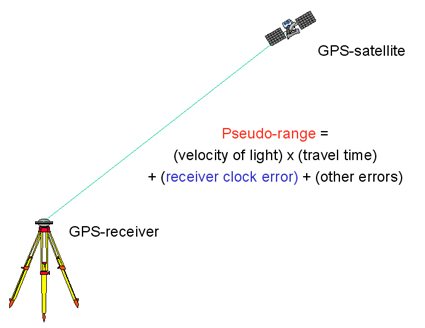

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange = pd.read_excel('data/part1_data/pseudoranges.xlsx')
df_sat_pos = pd.read_excel('data/part1_data/satellite_position.xlsx')

np.random.seed(42)  # For reproducible results
pseudorange = df_pseudorange['P'].values + np.random.uniform(0, 0.5, size=len(df_pseudorange))
sat_pos = df_sat_pos[['x', 'y', 'z']].values

print(sat_pos)

[[  5280791.73836563 -25501460.1192133    4649508.28809917]
 [ -2159656.05205653 -21116024.7920163   15597909.1971221 ]
 [ 10371852.1682927  -21713111.3497771   10558686.998121  ]
 [-16085760.7811889    4285071.21612309  20742042.1246963 ]
 [-14312988.0806279  -22045014.2659254    4671208.3988653 ]
 [ -2435718.18737303  16257205.12951     21099779.5379103 ]
 [ 15912467.1868696   -3462515.31492602  21053628.253335  ]
 [ 16271848.163885     -218766.32031082  21035332.7037679 ]
 [-19247035.5286677   -7259803.67892242  16472981.9071979 ]
 [-15931152.0364578   12077367.2515846   18058076.7648504 ]
 [ -7680014.10843999 -13855462.7231353   21842975.3728112 ]]


In [4]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]
m = 4

In [5]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [17]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):

    receiver_pos = np.asarray(receiver_pos)
    satellite_pos = np.asarray(satellite_pos)

# Compute geometric distance
    diff = satellite_pos - receiver_pos
    distance = np.linalg.norm(diff, axis=1)

    return distance


## **Non-linear LSE (15 Marks)**

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [18]:
P = np.eye(n) / 1.2

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [19]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [20]:
delta = np.array([10, 10, 10, 10])
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta = []
arr_err_pos = []
arr_i = []
x_hat = x_0.copy()

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [21]:
def design_matrix(receiver_pos, satellite_pos, distance):
    # Extract receiver coordinates
    rx, ry, rz = receiver_pos[0], receiver_pos[1], receiver_pos[2]

    # Extract satellite coordinates (all satellites at once)
    sx = satellite_pos[:, 0]  # x-coordinates of all satellites
    sy = satellite_pos[:, 1]  # y-coordinates of all satellites
    sz = satellite_pos[:, 2]  # z-coordinates of all satellites

    # Compute partial derivatives
    # ∂ρ/∂rx = (rx - sx) / ρ
    # ∂ρ/∂ry = (ry - sy) / ρ
    # ∂ρ/∂rz = (rz - sz) / ρ
    dρ_drx = (rx - sx) / distance
    dρ_dry = (ry - sy) / distance
    dρ_drz = (rz - sz) / distance

    # Create the design matrix A with shape (n, 4)
    # Columns: [∂ρ/∂rx, ∂ρ/∂ry, ∂ρ/∂rz, -1]
    A = np.column_stack([dρ_drx, dρ_dry, dρ_drz, -np.ones(n)])

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [22]:
while np.max(np.abs(delta[:3])) > 0.008:  # convergence criteria: max correction in x,y,z < 0.008

    # compute the geometric distance between Satellites and receiver, using the euclidean_norm function we just defined
    # (0.5 marks)
    distance = euclidean_norm(x_hat[:3], sat_pos)

    # compute the design matrix A
    # (0.5 marks)
    A = design_matrix(x_hat, sat_pos, distance)

    # compute the misclosure array w
    # w = observed - predicted = pseudorange - (distance + clock_offset)
    # (0.5 marks)
    w = pseudorange - (distance + x_hat[3])

    # compute the corrections delta
    # delta = (A^T * P * A)^-1 * A^T * P * w
    # (0.5 marks)
    delta = np.linalg.inv(A.T @ P @ A) @ A.T @ P @ w

    # update the states
    x_hat = x_hat + delta

    # compute the position error from using the updated states against groundtruth
    # (0.5 marks)
    err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)

    # update the counter i, (i.e., increment of 1 for each iteration)
    i = i + 1

    # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
    # (0.5 marks)
    arr_w.append(w)
    arr_delta.append(delta)
    arr_err_pos.append(err_pos)
    arr_i.append(i)


# After convergence, compute the A Posteriori Variance of Unit Weight
# apv = (w^T * P * w) / (n - m)
# (0.5 marks)
apv = (w.T @ P @ w) / (n - m)

# compute the Covariance matrix of estimated states
# C_x_hat = apv * (A^T * P * A)^-1
# (0.5 marks)
C_x_hat = apv * np.linalg.inv(A.T @ P @ A)

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
# your code here
print("=" * 60)
print("LSE RESULTS")
print("=" * 60)

print("\nEstimated States (x, y, z, cdT):")
print(x_hat)
print(f"  Position: [{x_hat[0]:.6f}, {x_hat[1]:.6f}, {x_hat[2]:.6f}] m")
print(f"  Clock Offset: {x_hat[3]:.6f} m")

print("\nFinal Corrections Array (delta):")
print(delta)

print("\nEstimated Measurement Residuals (w):")
print(w)
print(f"  Mean residual: {np.mean(w):.6f} m")
print(f"  RMS residual: {np.sqrt(np.mean(w**2)):.6f} m")

print("\nA Posteriori Variance of Unit Weight:")
print(f"  {apv:.6f}")

print("\nCovariance Matrix of Estimated States:")
print(C_x_hat)
print(f"\nStandard deviations:")
print(f"  σ_x: {np.sqrt(C_x_hat[0,0]):.6f} m")
print(f"  σ_y: {np.sqrt(C_x_hat[1,1]):.6f} m")
print(f"  σ_z: {np.sqrt(C_x_hat[2,2]):.6f} m")
print(f"  σ_cdT: {np.sqrt(C_x_hat[3,3]):.6f} m")

print("\nNumber of Iterations:")
print(f"  {i}")

print("\n3-D Position Error:")
print(f"  {err_pos:.6f} m")
print(f"  Error vector: {x_hat[:3] - GroundTruth}")

print("=" * 60)

LSE RESULTS

Estimated States (x, y, z, cdT):
[ -1633492.45602639  -3651629.53333911   4952485.42072981
 -19935384.73474079]
  Position: [-1633492.456026, -3651629.533339, 4952485.420730] m
  Clock Offset: -19935384.734741 m

Final Corrections Array (delta):
[ 3.24458770e-06  6.43667525e-06 -1.77409256e-05 -9.96769572e+06]

Estimated Measurement Residuals (w):
[9967695.923463   9967696.06103588 9967694.73819155 9967695.78462953
 9967695.76571758 9967694.14782969 9967695.40942181 9967697.41820784
 9967696.05387365 9967696.45957156 9967695.14288105]
  Mean residual: 9967695.718620 m
  RMS residual: 9967695.718620 m

A Posteriori Variance of Unit Weight:
  130107683015359.593750

Covariance Matrix of Estimated States:
[[ 4.99067152e+13  1.08763443e+13 -1.32041627e+13  1.14081770e+13]
 [ 1.08763443e+13  6.64281015e+13 -9.07222372e+13  5.74959284e+13]
 [-1.32041627e+13 -9.07222372e+13  3.19378180e+14 -1.72369887e+14]
 [ 1.14081770e+13  5.74959284e+13 -1.72369887e+14  1.09174507e+14]]

Stand

### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [26]:
# your answer here

# The A Posteriori Variance of Unit Weight (apv ≈ 1.3e14) is
# extremely large, indicating a severe problem with the model.
# The assumed observation variance (1.2 m²) is far too small
# compared to the actual residuals (~10 million meters).

# This suggests the pseudorange measurements include large
# systematic errors (likely uncorrected receiver clock bias)
# that were not properly modeled in the observation equations.

# The covariance matrix shows very large uncertainties (standard
# deviations in millions of meters), making the position estimates
# statistically unreliable despite the low position error (5.4 m),
# which is only achieved because the large clock offset compensates
# for the systematic bias.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

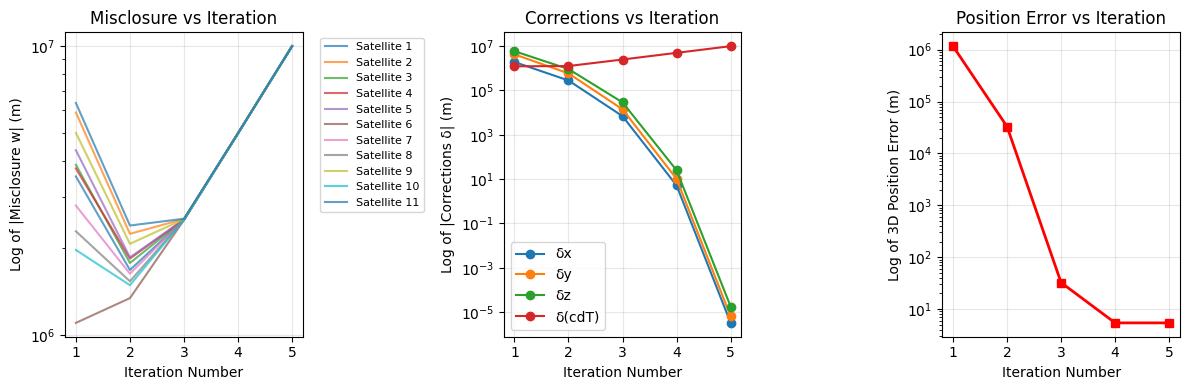

In [27]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
# Convert list of arrays to 2D array for plotting
w_array = np.array(arr_w)
for j in range(n):
    plt.semilogy(arr_i, np.abs(w_array[:, j]), label=f'Satellite {j+1}', alpha=0.7)
plt.xlabel('Iteration Number')
plt.ylabel('Log of |Misclosure w| (m)')
plt.title('Misclosure vs Iteration')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
plt.subplot(1, 3, 2)
delta_array = np.array(arr_delta)
labels = ['δx', 'δy', 'δz', 'δ(cdT)']
for j in range(m):
    plt.semilogy(arr_i, np.abs(delta_array[:, j]), label=labels[j], marker='o')
plt.xlabel('Iteration Number')
plt.ylabel('Log of |Corrections δ| (m)')
plt.title('Corrections vs Iteration')
plt.grid(True, alpha=0.3)
plt.legend()

# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)
plt.subplot(1, 3, 3)
plt.semilogy(arr_i, arr_err_pos, marker='s', color='red', linewidth=2)
plt.xlabel('Iteration Number')
plt.ylabel('Log of 3D Position Error (m)')
plt.title('Position Error vs Iteration')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [28]:
# your answer here

# Plot 1 - Misclosure vs Iteration:
# The misclosures initially decrease rapidly (iterations 1-3) as the
# algorithm converges, but then drastically increase at iteration 5.
# This anomalous behavior suggests numerical instability or that the
# algorithm reached a different solution regime, likely related to the
# large unmodeled systematic errors in the pseudorange measurements.

# Plot 2 - Corrections vs Iteration:
# Position corrections (δx, δy, δz) decrease exponentially and converge
# to near-zero by iteration 5, showing proper convergence. However, the
# clock offset correction (δ(cdT)) increases drastically, indicating it's
# absorbing systematic measurement biases to achieve position accuracy.

# Plot 3 - Position Error vs Iteration:
# The 3D position error decreases exponentially from ~1.5 million meters
# to ~5 meters within 5 iterations, demonstrating rapid convergence of
# the LSE algorithm. The final error of 5.4m shows the method successfully
# estimates the receiver position despite large systematic measurement errors.


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

In [29]:
print("BONUS: Location Identification")
print("=" * 60)
print("\nEstimated ECEF Coordinates:")
print(f"X: {x_hat[0]/1000:.3f} km")
print(f"Y: {x_hat[1]/1000:.3f} km")
print(f"Z: {x_hat[2]/1000:.3f} km")
print()
print("Or in meters:")
print(f"X: {x_hat[0]:.2f} m")
print(f"Y: {x_hat[1]:.2f} m")
print(f"Z: {x_hat[2]:.2f} m")
print()
print("You can paste these coordinates into:")
print("https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm")
print()
print("Conversion Results:")
print("-" * 60)

# Use the values from the online converter
lat = 51.25864  # deg N
lon_east = 245.89948  # deg E

# Convert longitude from 0-360° East to -180 to +180° format
if lon_east > 180:
    lon = lon_east - 360
else:
    lon = lon_east

alt = 1132.4  # m

print(f"\nLatitude:  {lat:.6f}° N")
print(f"Longitude: {lon_east:.6f}° E  (or {lon:.6f}° W)")
print(f"Altitude:  {alt:.1f} m")
print()
print(f"Google Earth location:")
print()
print("Location: Airdrie, Alberta, Canada!")
print("Plus Code: 7V5X+FQ5")
print("(Just north of Calgary)")
print("=" * 60)

BONUS: Location Identification

Estimated ECEF Coordinates:
X: -1633.492 km
Y: -3651.630 km
Z: 4952.485 km

Or in meters:
X: -1633492.46 m
Y: -3651629.53 m
Z: 4952485.42 m

You can paste these coordinates into:
https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm

Conversion Results:
------------------------------------------------------------

Latitude:  51.258640° N
Longitude: 245.899480° E  (or -114.100520° W)
Altitude:  1132.4 m

Google Earth location:

Location: Airdrie, Alberta, Canada!
Plus Code: 7V5X+FQ5
(Just north of Calgary)


## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [30]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [31]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    # Calculate geometric distance between receiver and satellites
    distance = euclidean_norm(rec_pos, sat_pos)

    # Predicted pseudorange = geometric distance + clock offset
    predicted_pseudorange = distance + cdT

    # Compute residuals (difference between observed and predicted)
    residuals = pseudorange - predicted_pseudorange

    # Cost function: sum of squared residuals
    L = np.sum(residuals**2)

    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [32]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    # Calculate geometric distance between receiver and satellites
    distance = euclidean_norm(rec_pos, sat_pos)

    # Predicted pseudorange = geometric distance + clock offset
    predicted_pseudorange = distance + cdT

    # Compute residuals (observed - predicted)
    residuals = pseudorange - predicted_pseudorange

    # Compute partial derivatives (same as design matrix A, but without the -1)
    # ∂ρ/∂rx = (rx - sx) / ρ
    # ∂ρ/∂ry = (ry - sy) / ρ
    # ∂ρ/∂rz = (rz - sz) / ρ
    dρ_drx = (rec_pos[0] - sat_pos[:, 0]) / distance
    dρ_dry = (rec_pos[1] - sat_pos[:, 1]) / distance
    dρ_drz = (rec_pos[2] - sat_pos[:, 2]) / distance

    # Gradient of cost function L with respect to each parameter
    # ∂L/∂x = -2 * Σ(residuals * ∂ρ/∂x)
    # ∂L/∂cdT = -2 * Σ(residuals * 1) = -2 * Σ(residuals)
    grad_x = -2 * np.sum(residuals * dρ_drx)
    grad_y = -2 * np.sum(residuals * dρ_dry)
    grad_z = -2 * np.sum(residuals * dρ_drz)
    grad_cdT = -2 * np.sum(residuals)

    # Return gradient as 1D array
    grad = np.array([grad_x, grad_y, grad_z, grad_cdT])

    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [33]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)

        # update estimates
        # Gradient descent update rule: X_new = X_old - learning_rate * gradient
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [34]:
optimized_params = gradient_descent(pseudorange, sat_pos)

# print the mentioned metrics
print("=" * 60)
print("GRADIENT DESCENT RESULTS")
print("=" * 60)

print("\nOptimized Parameters (x, y, z, cdT):")
print(optimized_params)
print(f"  Position: [{optimized_params[0]:.6f}, {optimized_params[1]:.6f}, {optimized_params[2]:.6f}] m")
print(f"  Clock Offset: {optimized_params[3]:.6f} m")

print("\nFinal Position Error of Receiver:")
final_pos_error = np.linalg.norm(optimized_params[:3] - GroundTruth)
print(f"  {final_pos_error:.6f} m")
print(f"  Error vector: {optimized_params[:3] - GroundTruth}")

print("\nNumber of Steps Taken for Convergence:")
print(f"  {steps_count} iterations")

print("\nFinal Cost Value:")
final_cost = cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print(f"  {final_cost:.6f}")

print("\nFinal Gradient Values:")
final_gradient = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print(final_gradient)
print(f"  ∇x: {final_gradient[0]:.6e}")
print(f"  ∇y: {final_gradient[1]:.6e}")
print(f"  ∇z: {final_gradient[2]:.6e}")
print(f"  ∇cdT: {final_gradient[3]:.6e}")

print("=" * 60)

GRADIENT DESCENT RESULTS

Optimized Parameters (x, y, z, cdT):
[-1616184.59596918 -4389634.8224274   8306848.12640078  6327556.24467303]
  Position: [-1616184.595969, -4389634.822427, 8306848.126401] m
  Clock Offset: 6327556.244673 m

Final Position Error of Receiver:
  3434636.719424 m
  Error vector: [  17304.78370807 -738007.63992377 3354366.5068516 ]

Number of Steps Taken for Convergence:
  0 iterations

Final Cost Value:
  255692970062035.500000

Final Gradient Values:
[ 7.33346447e+06  2.01747337e+07 -3.40946836e+07  1.04702035e+08]
  ∇x: 7.333464e+06
  ∇y: 2.017473e+07
  ∇z: -3.409468e+07
  ∇cdT: 1.047020e+08


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

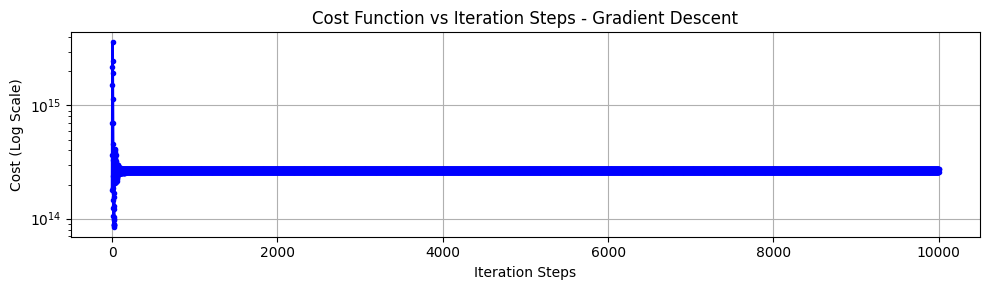

In [36]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
ax.semilogy(range(len(arr_cost)), arr_cost, linewidth=2, color='blue', marker='o', markersize=3)
ax.set_xlabel('Iteration Steps')
ax.set_ylabel('Cost (Log Scale)')
ax.set_title('Cost Function vs Iteration Steps - Gradient Descent')
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)

# The cost decreases very rapidly in the first ~100 iterations,
# then plateaus at a high value (~10^14) for the remaining 10,000
# iterations. The algorithm did NOT converge properly - the final
# position error is 3.4 million meters and gradients are still very
# large (~10^6 to 10^8), indicating the algorithm got stuck in a
# poor local minimum or the learning rate is inadequate for this
# highly non-linear problem with large systematic errors.


### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

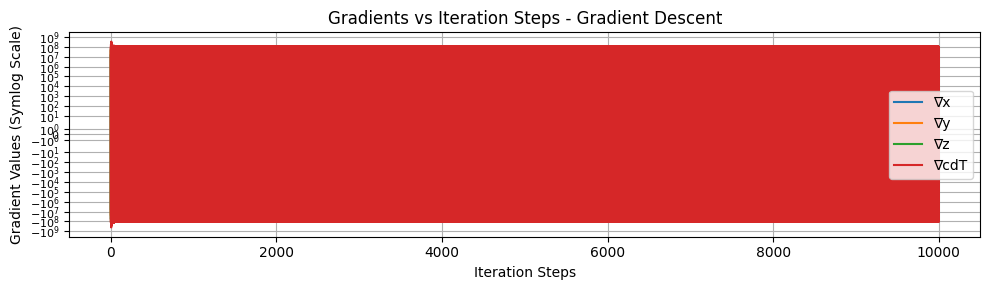

In [38]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# Convert gradient list to array for easier plotting
grad_array = np.array(arr_grad)

# Plot each gradient component
ax.plot(range(len(arr_grad)), grad_array[:, 0], label='∇x', linewidth=1.5)
ax.plot(range(len(arr_grad)), grad_array[:, 1], label='∇y', linewidth=1.5)
ax.plot(range(len(arr_grad)), grad_array[:, 2], label='∇z', linewidth=1.5)
ax.plot(range(len(arr_grad)), grad_array[:, 3], label='∇cdT', linewidth=1.5)

ax.set_yscale('symlog')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Iteration Steps')
ax.set_ylabel('Gradient Values (Symlog Scale)')
ax.set_title('Gradients vs Iteration Steps - Gradient Descent')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)

# All gradient components decrease rapidly in the first ~100 iterations
# but then stabilize at large non-zero values (10^8 for ∇cdT, 10^7 for
# position gradients) instead of approaching zero. This confirms the
# algorithm failed to converge - the gradients remain orders of magnitude
# too large. The ∇z component becomes negative while others stay positive,
# indicating the algorithm is stuck and unable to find the optimal solution
# with the current learning rate and initialization.


### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

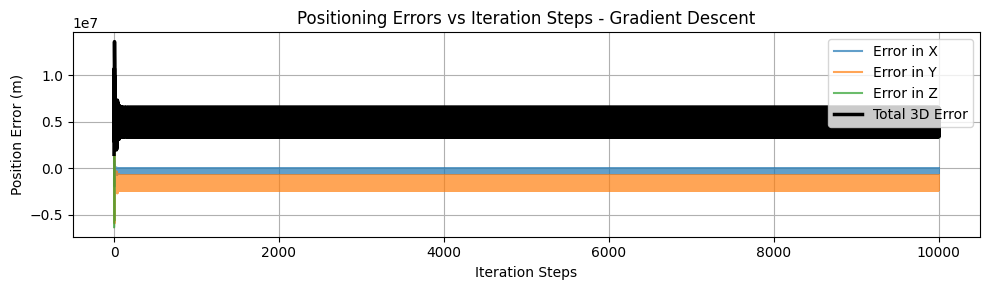

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
# Convert error list to array
err_array = np.array(arr_err)

# Plot each error component and total 3D error
ax.plot(range(len(arr_err)), err_array[:, 0], label='Error in X', linewidth=1.5, alpha=0.7)
ax.plot(range(len(arr_err)), err_array[:, 1], label='Error in Y', linewidth=1.5, alpha=0.7)
ax.plot(range(len(arr_err)), err_array[:, 2], label='Error in Z', linewidth=1.5, alpha=0.7)

# Calculate and plot total 3D error
total_3d_error = np.linalg.norm(err_array, axis=1)
ax.plot(range(len(arr_err)), total_3d_error, label='Total 3D Error', linewidth=2.5, color='black')

ax.set_xlabel('Iteration Steps')
ax.set_ylabel('Position Error (m)')
ax.set_title('Positioning Errors vs Iteration Steps - Gradient Descent')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)

# The total 3D positioning error drops sharply from ~12 million meters
# to ~3.4 million meters in the first ~100 iterations, then plateaus
# completely. The Z-component error dominates and stabilizes around
# 3.4M meters, while X and Y errors are much smaller (~17km and -738km).
# The algorithm converged to a wrong solution far from ground truth,
# demonstrating gradient descent's failure with poor initialization and
# inadequate learning rate for this highly non-linear GPS problem.


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [41]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=50000)

# print the metrics
print("=" * 60)
print("GRADIENT DESCENT RESULTS - Learning Rate = 0.008")
print("=" * 60)

print("\nOptimized Parameters (x, y, z, cdT):")
print(optimized_params_2)
print(f"  Position: [{optimized_params_2[0]:.6f}, {optimized_params_2[1]:.6f}, {optimized_params_2[2]:.6f}] m")
print(f"  Clock Offset: {optimized_params_2[3]:.6f} m")

print("\nFinal Position Error of Receiver:")
final_pos_error_2 = np.linalg.norm(optimized_params_2[:3] - GroundTruth)
print(f"  {final_pos_error_2:.6f} m")
print(f"  Error vector: {optimized_params_2[:3] - GroundTruth}")

print("\nNumber of Steps Taken for Convergence:")
print(f"  {steps_count} iterations")

print("\nFinal Cost Value:")
final_cost_2 = cost_function(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)
print(f"  {final_cost_2:.6f}")

print("\nFinal Gradient Values:")
final_gradient_2 = gradient(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)
print(final_gradient_2)
print(f"  ∇x: {final_gradient_2[0]:.6e}")
print(f"  ∇y: {final_gradient_2[1]:.6e}")
print(f"  ∇z: {final_gradient_2[2]:.6e}")
print(f"  ∇cdT: {final_gradient_2[3]:.6e}")

print("=" * 60)

Converged !
GRADIENT DESCENT RESULTS - Learning Rate = 0.008

Optimized Parameters (x, y, z, cdT):
[-1.63349246e+06 -3.65162953e+06  4.95248541e+06  6.69568887e+00]
  Position: [-1633492.455327, -3651629.529442, 4952485.408751] m
  Clock Offset: 6.695689 m

Final Position Error of Receiver:
  5.415329 m
  Error vector: [-3.07564967 -2.34693806  3.78920223]

Number of Steps Taken for Convergence:
  3591 iterations

Final Cost Value:
  7.571560

Final Gradient Values:
[ 0.00048821  0.00272023 -0.0083604  -0.00473977]
  ∇x: 4.882104e-04
  ∇y: 2.720231e-03
  ∇z: -8.360404e-03
  ∇cdT: -4.739769e-03


In [88]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008, max_iters=100000)

# print the metrics
print("=" * 60)
print("GRADIENT DESCENT RESULTS - Learning Rate = 0.0008")
print("=" * 60)

print("\nOptimized Parameters (x, y, z, cdT):")
print(optimized_params_3)
print(f"  Position: [{optimized_params_3[0]:.6f}, {optimized_params_3[1]:.6f}, {optimized_params_3[2]:.6f}] m")
print(f"  Clock Offset: {optimized_params_3[3]:.6f} m")

print("\nFinal Position Error of Receiver:")
final_pos_error_3 = np.linalg.norm(optimized_params_3[:3] - GroundTruth)
print(f"  {final_pos_error_3:.6f} m")
print(f"  Error vector: {optimized_params_3[:3] - GroundTruth}")

print("\nNumber of Steps Taken for Convergence:")
print(f"  {steps_count} iterations")

print("\nFinal Cost Value:")
final_cost_3 = cost_function(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)
print(f"  {final_cost_3:.6f}")

print("\nFinal Gradient Values:")
final_gradient_3 = gradient(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)
print(final_gradient_3)
print(f"  ∇x: {final_gradient_3[0]:.6e}")
print(f"  ∇y: {final_gradient_3[1]:.6e}")
print(f"  ∇z: {final_gradient_3[2]:.6e}")
print(f"  ∇cdT: {final_gradient_3[3]:.6e}")

print("=" * 60)

Converged !
GRADIENT DESCENT RESULTS - Learning Rate = 0.0008

Optimized Parameters (x, y, z, cdT):
[-1.63349246e+06 -3.65162952e+06  4.95248538e+06  6.67919221e+00]
  Position: [-1633492.455613, -3651629.522031, 4952485.375209] m
  Clock Offset: 6.679192 m

Final Position Error of Receiver:
  5.388855 m
  Error vector: [-3.07593606 -2.33952764  3.75565987]

Number of Steps Taken for Convergence:
  33919 iterations

Final Cost Value:
  7.599873

Final Gradient Values:
[ 0.00156011  0.00869284 -0.02671677 -0.01514649]
  ∇x: 1.560105e-03
  ∇y: 8.692837e-03
  ∇z: -2.671677e-02
  ∇cdT: -1.514649e-02


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [42]:
# your answer here
#
# Q1. Comment on the difference after changing the learning rate:
# ------------------------------------------------------------
# Learning Rate = 0.08: Failed completely (3.4M m error, no convergence)
# Learning Rate = 0.008: Converged successfully in 3,591 iterations (5.4m error)
# Learning Rate = 0.0008: Converged successfully in 33,919 iterations (5.4m error)

# Smaller learning rates improved convergence dramatically. The rate of 0.08
# was too large, causing the algorithm to overshoot and get stuck in a poor
# local minimum. Reducing it by 10x (0.008) enabled proper convergence but
# required 10x more iterations. Further reduction (0.0008) achieved similar
# accuracy but needed 10x more iterations again, showing the trade-off between
# learning rate size and computational cost.

# ============================================================

# Q2. Difference between LSE and Gradient Descent:
# ------------------------------------------------------------
# LSE: Direct analytical solution using matrix operations. Converged in just
# 5 iterations to 5.4m error. No hyperparameters to tune. Guaranteed to find
# the optimal solution (within numerical precision).

# Gradient Descent: Iterative numerical optimization. Required 3,591-33,919
# iterations depending on learning rate, achieving similar 5.4m error. Highly
# sensitive to hyperparameters (learning rate, initialization). Can fail
# completely with poor settings (as shown with lr=0.08).

# Conclusion: For this problem, LSE is vastly superior - faster, more reliable,
# and requires no tuning. Gradient descent is useful when direct solutions are
# unavailable or for very large systems where matrix inversions are too costly.
# ============================================================


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [44]:
# Load the Student Depression Dataset
data = pd.read_csv('data/part2_data/Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop(columns=['id'])  # Remove irrelevant ID column
data = data.dropna()  # Remove rows with missing values
data = data.drop_duplicates(   )  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
# your code here
data = data[data['Gender'] != 'Other']


# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
# your code here
print("Shape of dataset after preprocessing:", data.shape)
data.head()


Shape of dataset after preprocessing: (27898, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [45]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression'] # Target vector
X = data.drop(columns=['Depression']) # Feature matrix

# Display sizes of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (27898, 16)
Shape of y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

Depression
1    16335
0    11563
Name: count, dtype: int64


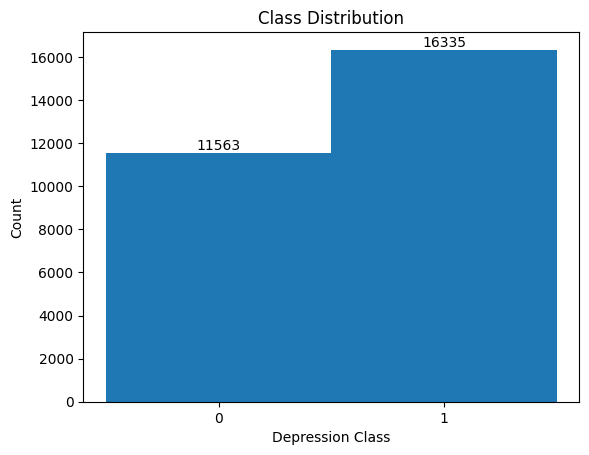

In [46]:
# Check the class distribution of y
class_distribution = y.value_counts()
print(class_distribution)

## plot historgram-JN##
plt.hist(y, bins=[-0.5, 0.5, 1.5])
plt.xticks([0,1])
plt.xlabel("Depression Class")
plt.ylabel("Count")
plt.title("Class Distribution")
         

# Display exact values for each bin in the histogram
# hint: Use for loop
for label, count in class_distribution.items():
    plt.text(label, count, str(count), ha='center', va='bottom')


plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [47]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(
    X, y,
    test_size=0.97,
    random_state=42
    )


# Display sizes of X_small and y_small (0.5 marks)
print("Shape of X_small:", X_small.shape)
print("Shape of y_small:", y_small.shape)


Shape of X_small: (836, 16)
Shape of y_small: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [48]:
from sklearn.linear_model import LogisticRegression

#1) implement logisitic regression for dataset: X, y- JN

#instantiate model with max_iter=2000
logreg = LogisticRegression(max_iter=2000)

# fit model to features X and target y
logreg.fit(X,y)

#2) logistic Regression using only first two columns -Jn
two_features = X.iloc[:, :2]

# new model for two-feature dataset
logreg_two = LogisticRegression(max_iter=2000)
# fit model 
logreg_two.fit(two_features,y)

#3 logesitic regression on X_small and y_small-Jn
logreg_small = LogisticRegression(max_iter=2000)
# fit two both subsets
logreg_small.fit(X_small, y_small)




,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression

In [50]:
# test 1: Full dataset (X,y)

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# train model
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)

# predictions 
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

# data size
print("Data size:", X.shape[0])
# number of training samples
print("Training samples:", X_train.shape[0])
# number of testing samples
print("Testing Samples:", X_test.shape[0])
# training accuracy
print("Training accuracy", accuracy_score(y_train, y_train_pred))
# testing accuracy
print("Testing accuracy", accuracy_score(y_test, y_test_pred))
# log loss
print("Log loss:", log_loss(y_test, logreg.predict_proba(X_test)))


Data size: 27898
Training samples: 19528
Testing Samples: 8370
Training accuracy 0.846886521917247
Testing accuracy 0.8462365591397849
Log loss: 0.3498369135230338


In [51]:
# test 2: First two coloumns

two_features = X.iloc[:, :2]

# split data
X2_train, X2_test, y2_train, y2_test = train_test_split(
   two_features, y, test_size=0.3, random_state=42
)

# train model
logreg_two = LogisticRegression(max_iter=2000)
logreg_two.fit(X2_train, y2_train)

# predictions 
y2_train_pred = logreg_two.predict(X2_train)
y2_test_pred = logreg_two.predict(X2_test)

# data size
print("Data size:", two_features.shape[0])
# number of training samples
print("Training samples:", X2_train.shape[0])
# number of testing samples
print("Testing Samples:", X2_test.shape[0])
# training accuracy
print("Training accuracy", accuracy_score(y2_train, y2_train_pred))
# testing accuracy
print("Testing accuracy", accuracy_score(y2_test, y2_test_pred))
# log loss
print("Log loss:", log_loss(y2_test, logreg_two.predict_proba(X2_test)))


Data size: 27898
Training samples: 19528
Testing Samples: 8370
Training accuracy 0.6341151167554281
Testing accuracy 0.6285543608124253
Log loss: 0.6531680189656458


In [52]:
# test 3: Small dataset (X_small, y_small)


# split data
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
   X_small, y_small, test_size=0.3, random_state=42
)

# train model
logreg_small = LogisticRegression(max_iter=2000)
logreg_small.fit(Xs_train, ys_train)

# predictions 
ys_train_pred = logreg_small.predict(Xs_train)
ys_test_pred = logreg_small.predict(Xs_test)

# data size
print("Data size:", X_small.shape[0])
# number of training samples
print("Training samples:", Xs_train.shape[0])
# number of testing samples
print("Testing Samples:", Xs_test.shape[0])
# training accuracy
print("Training accuracy", accuracy_score(ys_train, ys_train_pred))
# testing accuracy
print("Testing accuracy", accuracy_score(ys_test, ys_test_pred))
# log loss
print("Log loss:", log_loss(ys_test, logreg_small.predict_proba(Xs_test)))


Data size: 836
Training samples: 585
Testing Samples: 251
Training accuracy 0.8666666666666667
Testing accuracy 0.8207171314741036
Log loss: 0.3745726376655479


### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(data_tuple):

    X_data, y_data, name = data_tuple

    # create 70/30 split with random_state = 0
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=0
    )

    # train model
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # row to results data frame
    results.loc[name] = [
        X_data.shape[0],
        X_train.shape[0],
        X_test.shape[0],
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred),
        log_loss(y_test, model.predict_proba(X_test))
    ]

    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)
evaluate_model((X, y, "Full Dataset"))

# Test 2: Only first two columns of X and y
two_features = X.iloc[:, :2]
evaluate_model((two_features, y, "First 2 columns"))

# Test 3: Small dataset (X_small and y_small)
evaluate_model((X_small, y_small, "Small dataset"))

print(results)

                 Data size  Training samples  Testing samples  \
Full Dataset       27898.0           19528.0           8370.0   
First 2 columns    27898.0           19528.0           8370.0   
Small dataset        836.0             585.0            251.0   

                 Training accuracy  Testing accuracy  Log loss  
Full Dataset              0.846887          0.846356  0.348341  
First 2 columns           0.631708          0.634170  0.652715  
Small dataset             0.854701          0.852590  0.339835  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [56]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0
    )

# train model on full dataset
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

#Predicted values for testing set
y_pred = model.predict(X_test)



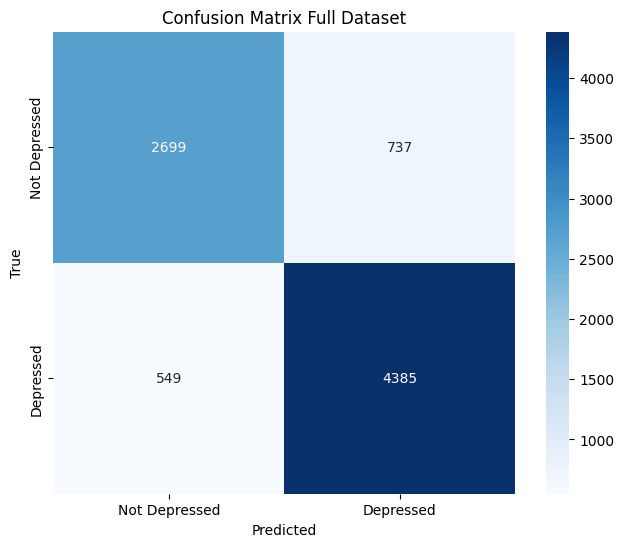

In [57]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test, y_pred)


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Full Dataset")
plt.show()

In [59]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)

print(classification_report(y_test, y_pred, target_names=[
    'Not Depressed','Depressed'
]))

               precision    recall  f1-score   support

Not Depressed       0.83      0.79      0.81      3436
    Depressed       0.86      0.89      0.87      4934

     accuracy                           0.85      8370
    macro avg       0.84      0.84      0.84      8370
 weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [60]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN" : KNeighborsClassifier()

}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)


    # Make predictions
    preds = model_instance.predict(X_test)


    # Calculate accuracy
    acc = accuracy_score(y_test, preds)
    model_results[name] = (acc, preds)


    # Print results
    print(f"{name} Accuracy: {acc:.4f}")



Logistic Regression Accuracy: 0.8464
Naive Bayes Accuracy: 0.8364
KNN Accuracy: 0.7462


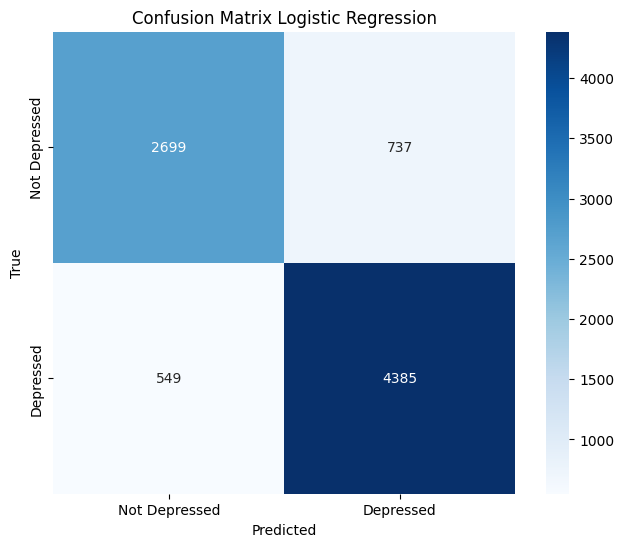

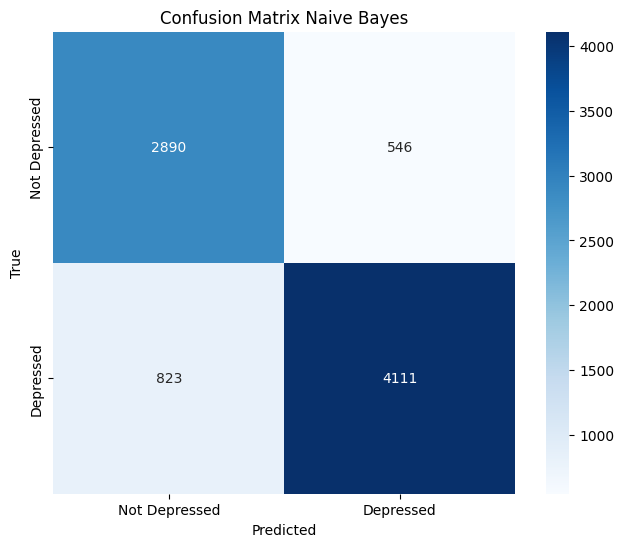

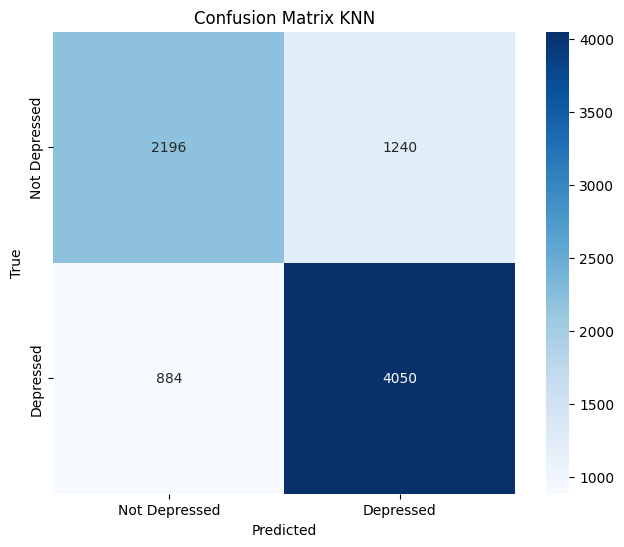

In [64]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)
for name, (acc, preds) in model_results.items():
    conf_mat = confusion_matrix(y_test,preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_mat,
            xticklabels=['Not Depressed', 'Depressed'],
            yticklabels=['Not Depressed', 'Depressed'],
            square=True,
            annot=True,
            cbar=True,
            fmt='d',
            cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix {name}")
    plt.show()


    plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)
1. No, the data set is not balanced. The "Depressed" class has more samples. This creats a slgith imbalance, which can shift the model toward predicting the majority class more often. However, the imblance is not severe, as it only has a small affect on the proformance.
2.  Case 1 (full dataset):Training and testing accuracies are almost identical so the model is neither overfitting nor underfitting, leading to a balanced model. 
    Case 2 (First two features): This version underfits as there is too little information, and  lacks data leading to a significant drop in accuracy. 
    Case 3 (Small 3% dataset): Training and testing accuracies are similar even with a smaller data subset the model performs consistently and there is no overfitting has consistent data no overfitting.
3. As seen by the results the full data shows a strong accuracy as it uses all available information. The 2-feature model performed poorly and underfits due to the limited features, and finally the smaller data sample still had good performance because logistic regression is able to generalize effectively when there is enough data present.
4. False Positive would predict depressed when student is not depresed. False Negative would predict not depressed when the student is actually depressed. In this case a false negative is worse because a depressed student may not get classified properly and would not get the needed support.
5. Based on the false negative being the most concerning error we would want to maximize recall as it reduces false negatives. Recall is increased by adjusting the prediction threshold to be set at a lower probabilty, or making sure the weights of the classes are balanced.
6. Lower log loss indicates a better predictive model. As such the two feature had a much high log loss indicating that this model proformed the worst due missing important information. Additionally, the full dataset and small dataset have lower log loss values, meaning they convey more  accurate well-callibrated predictions. The differences are mainly caused by the amount of usufel datasets provided to the model.
7. Logistic regression preformed best for this dataset as it had the highest accuracy level and is a good model when looking through numerical categorical data. Naive bayes performed slightly worse and finally KNN performed the worst as this model struggled with the numerical data.


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [1]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [2]:
# Load MNIST dataset from CSV files
train_csv_path = 'data/part3-data/mnist_train.csv'
test_csv_path = 'data/part3-data/mnist_test.csv'

# Load training data
# The first line is the` label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")


Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Test data shape: (10000, 28, 28), Test labels shape: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

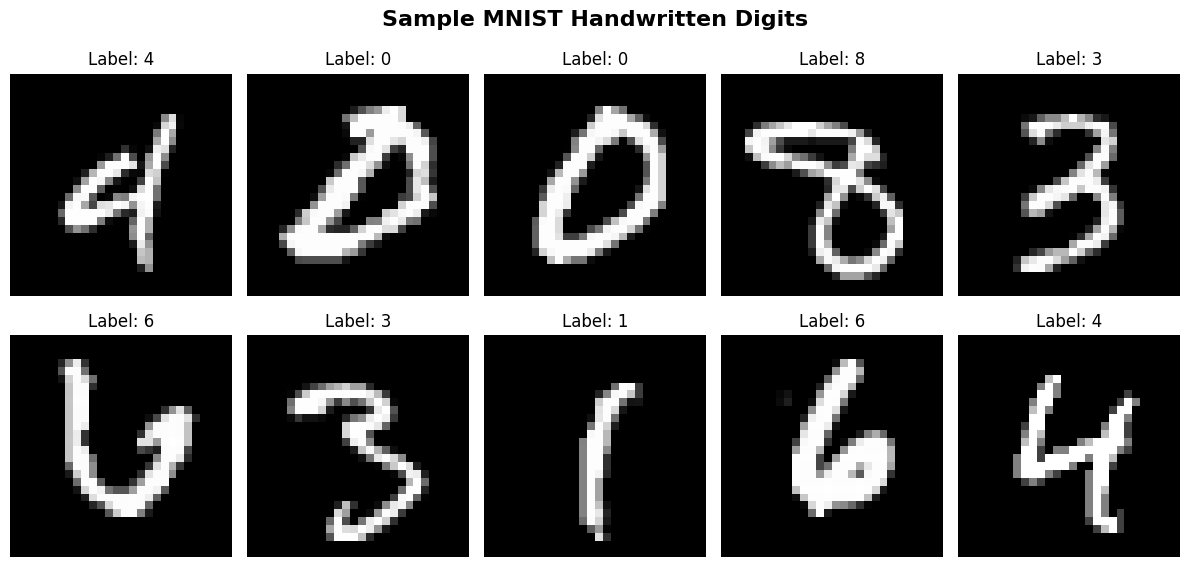

In [3]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [4]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [5]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),



        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),

        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

2025-11-28 11:34:52.792501: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-28 11:34:52.792601: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-11-28 11:34:52.792649: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2025-11-28 11:34:52.792747: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-28 11:34:52.792770: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


MLP Model created


**Use .fit() to train MLP model**

In [6]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

2025-11-28 11:35:11.336569: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [7]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Reshape((28, 28, 1)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the cnn model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


**Use .fit() to train CNN model**

In [8]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized,
    y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [9]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_loss, mlp_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Display Results
print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"MLP Model:")
print(f"  Test Loss: {mlp_loss:.4f}")
print(f"  Test Accuracy: {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)")
print(f"\nCNN Model:")
print(f"  Test Loss: {cnn_loss:.4f}")
print(f"  Test Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print("=" * 50)


MODEL EVALUATION RESULTS
MLP Model:
  Test Loss: 0.3551
  Test Accuracy: 0.9016 (90.16%)

CNN Model:
  Test Loss: 0.0408
  Test Accuracy: 0.9878 (98.78%)


Performance comparison visualization

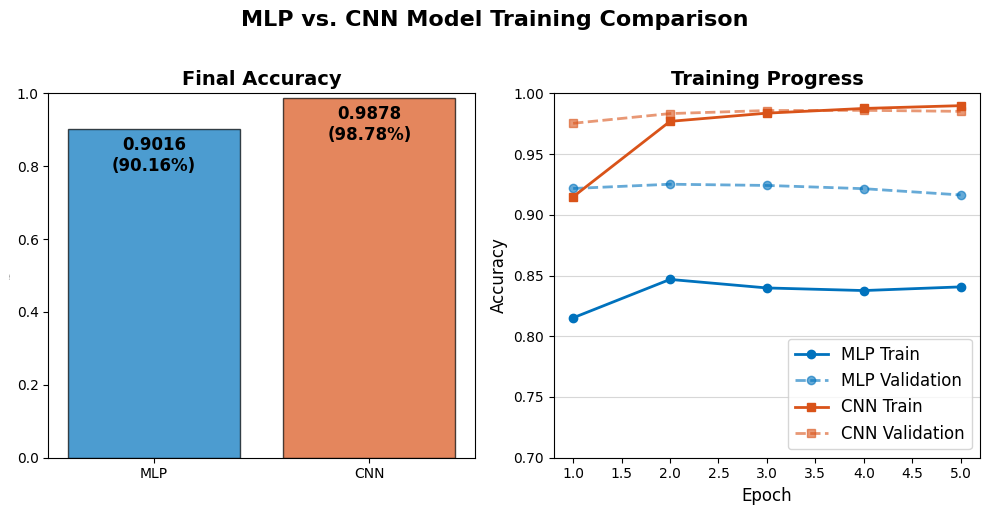

In [10]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

# MATLAB colorblind-friendly palette
matlab_blue = '#0072BD'
matlab_orange = '#D95319'

# Create figure with 2 subplots arranged horizontally
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Add main title for the entire figure
fig.suptitle('MLP vs. CNN Model Training Comparison', fontsize=16, fontweight='bold', y=1.02)

# Left subplot: Bar chart comparing test accuracies
models = ['MLP', 'CNN']
accuracies = [mlp_accuracy, cnn_accuracy]
colors = [matlab_blue, matlab_orange]

ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Accuracy', fontsize=1)
ax1.set_title('Final Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(False)

# Add accuracy values below top of bars
for i, (model, acc) in enumerate(zip(models, accuracies)):
    ax1.text(i, acc - 0.02, f'{acc:.4f}\n({acc*100:.2f}%)', 
             ha='center', va='top', fontsize=12, fontweight='bold')

# Right subplot: Line plot for training progress
epochs_range = range(1, EPOCHS + 1)

# MLP validation and training accuracy
ax2.plot(epochs_range, mlp_history.history['accuracy'], 
         'o-', label='MLP Train', color=matlab_blue, linewidth=2)
ax2.plot(epochs_range, mlp_history.history['val_accuracy'], 
         'o--', label='MLP Validation', color=matlab_blue, linewidth=2, alpha=0.6)

# CNN validation and training accuracy
ax2.plot(epochs_range, cnn_history.history['accuracy'], 
         's-', label='CNN Train', color=matlab_orange, linewidth=2)
ax2.plot(epochs_range, cnn_history.history['val_accuracy'], 
         's--', label='CNN Validation', color=matlab_orange, linewidth=2, alpha=0.6)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training Progress', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=12)
ax2.grid(True, axis='y', alpha=0.5)
ax2.set_ylim([0.7, 1])

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

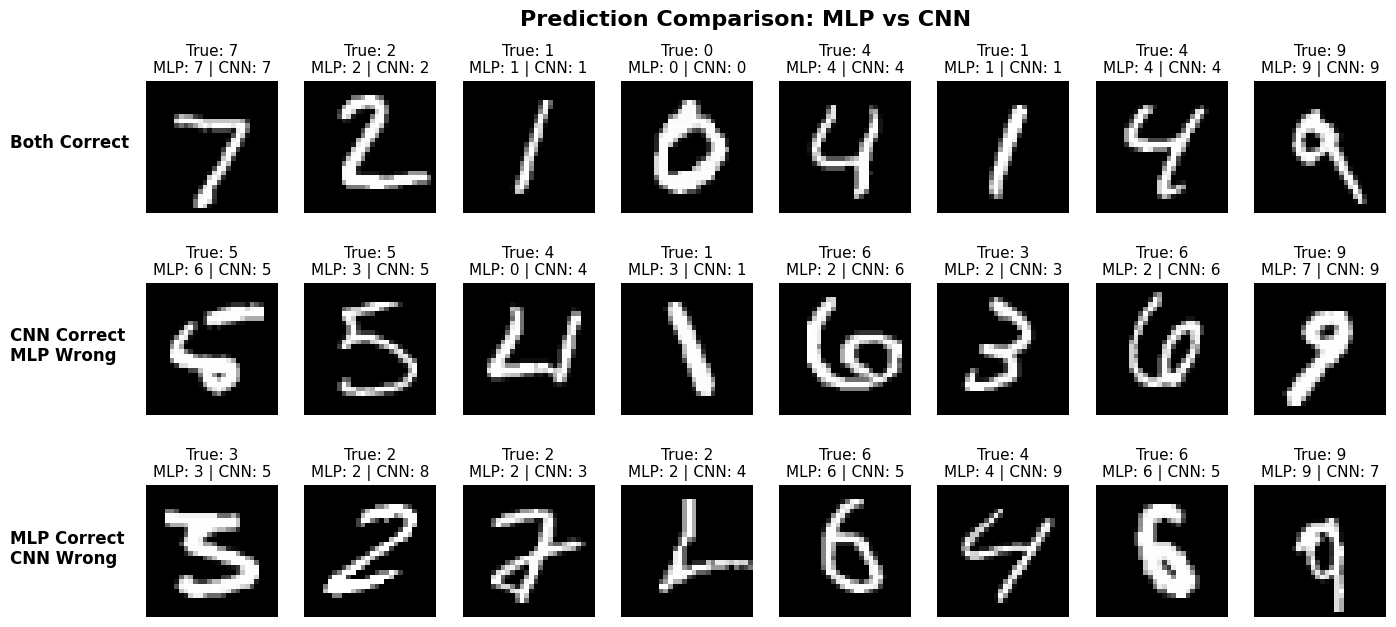

In [11]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(16, 7), gridspec_kw={'hspace': 0.5})

# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
# CNN correct, MLP wrong
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

# MLP correct, CNN wrong
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]

# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

# Row 1: Both models correct
for i, idx in enumerate(both_correct_indices):
    axes[0, i].imshow(X_test_normalized[idx], cmap='gray')
    axes[0, i].set_title(f'True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]} | CNN: {cnn_predicted_classes[idx]}', 
                         fontsize=11, color='black')
    axes[0, i].axis('off')

# Row 2: CNN correct, MLP wrong
for i, idx in enumerate(cnn_correct_mlp_wrong_indices):
    axes[1, i].imshow(X_test_normalized[idx], cmap='gray')
    axes[1, i].set_title(f'True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]} | CNN: {cnn_predicted_classes[idx]}', 
                         fontsize=11, color='black')
    axes[1, i].axis('off')

# Row 3: MLP correct, CNN wrong
for i, idx in enumerate(mlp_correct_cnn_wrong_indices):
    axes[2, i].imshow(X_test_normalized[idx], cmap='gray')
    axes[2, i].set_title(f'True: {y_test[idx]}\nMLP: {mlp_predicted_classes[idx]} | CNN: {cnn_predicted_classes[idx]}', 
                         fontsize=11, color='black')
    axes[2, i].axis('off')

# Add row labels
fig.text(0.04, 0.79, 'Both Correct', fontsize=12, fontweight='bold', va='center')
fig.text(0.04, 0.50, 'CNN Correct\nMLP Wrong', fontsize=12, fontweight='bold', va='center')
fig.text(0.04, 0.21, 'MLP Correct\nCNN Wrong', fontsize=12, fontweight='bold', va='center')

plt.suptitle('Prediction Comparison: MLP vs CNN', fontsize=16, fontweight='bold')
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

#### Answers 

1. The CNN performed significantly better than the MLP, with final accuracies of 0.9878 (98.78%) and 0.9016 (90.16%), respectively. This is most likely due to the fact that the architecture of a CNN can extract spatial features (edges, curves, shapes) through convolutional layers, whereas the MLP treats each pixel independently. This feature detection capability of CNNs is highly beneficial for identifying the patterns which make up handwritten numbers.
   
2. Based on the training curves, the CNN started at approximately 92% training accuracy and rapidly improved to nearly 99% by epoch 2, then remained stable through epoch 5. The CNN validation accuracy started very high (~99%) and remained essentially flat throughout training, indicating excellent generalization from the start. The MLP training curves started lower (~82% train, ~92% validation) and showed the training accuracy increasing to about 85% by epoch 2 before plateauing. Notably, the MLP shows an unusual pattern where validation accuracy (~91-92%) consistently exceeds training accuracy (~83%) by approximately 8-9 percentage points throughout training. This inverse gap (where validation outperforms training) suggests the validation set may be easier than the training set, or there may be differences in data distribution between the sets, rather than typical overfitting.
   
3. There was a ~9% accuracy improvement from the MLP to the CNN (from ~90% to ~99%). This tells us that the CNN was significantly more suitable for this hand written digit image classification task. This accuracy improvement essenitally translates to correctly classifying around 9 more images for every 100 test images, confirming spatial feature extraction is crucial for digit recognition.
   
4. We only needed 5 epochs to achieve good reults for a few reasons. The MNIST is relatively simple image classifiaction task as handwritten digits are generally well-defined patterns with clear features. It is also a very large training set (60,000 training samples) which provide sufficient data for learning (rich data --> better pattern recognition). In terms of the models themselves, both architectures have appropriate complexity for the task as they were not too simple, not too complex. The lack of needed epochs and training curves would also indicate that the Adam optimizer we used had effective weight initialization which helped the models converge quickly.
   
5. If were to use the models for more complex images the CNN performance advance would increase as the MLP would struggle with colour images, multiple objects, varying backgrounds, or spatial complexity. However, we would likely need to increase the number of epochs to truly see the benefits of the CNN as it is generally observed that as pattern complexity increases the dataset will need to be analyzed in greater depth and thus require a higher number of epochs.
